# Pivot()
pivot() is used to reshape a DataFrame.

- It takes values from rows and turn them into columns, creating a spreadsheet-like table.

**Rows → Columns**

In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('Datasets/matches.csv')
df.head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


In [6]:
season_wins = (
    df.groupby(["season", "winner"])
      .size()
      .reset_index(name="wins")
)

season_wins.head(10)

,season,winner,wins
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Daredevils,7
3,2008,Kings XI Punjab,10
4,2008,Kolkata Knight Riders,6
5,2008,Mumbai Indians,7
6,2008,Rajasthan Royals,13
7,2008,Royal Challengers Bangalore,4
8,2009,Chennai Super Kings,8
9,2009,Deccan Chargers,9


In [10]:
# use pivot()
result = season_wins.pivot(index = 'season' , columns = 'winner' , values = 'wins')
result

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,
2008,9.0,2.0,7.0,NaN,10.0,NaN,6.0,7.0,NaN,13.0,NaN,NaN,4.0,NaN
2009,8.0,9.0,10.0,NaN,7.0,NaN,3.0,5.0,NaN,6.0,NaN,NaN,9.0,NaN
2010,9.0,8.0,7.0,NaN,4.0,NaN,7.0,11.0,NaN,6.0,NaN,NaN,8.0,NaN
2011,11.0,6.0,4.0,NaN,7.0,6.0,8.0,10.0,4.0,6.0,NaN,NaN,10.0,NaN
2012,10.0,4.0,11.0,NaN,8.0,NaN,12.0,10.0,4.0,7.0,NaN,NaN,8.0,NaN
2013,12.0,NaN,3.0,NaN,8.0,NaN,6.0,13.0,4.0,11.0,NaN,NaN,9.0,10.0
2014,10.0,NaN,2.0,NaN,12.0,NaN,11.0,7.0,NaN,7.0,NaN,NaN,5.0,6.0
2015,10.0,NaN,5.0,NaN,3.0,NaN,7.0,10.0,NaN,7.0,NaN,NaN,8.0,7.0
2016,NaN,NaN,7.0,9.0,4.0,NaN,8.0,7.0,NaN,NaN,NaN,5.0,9.0,11.0


Do it directly with creating other dataframes

In [12]:
result = df.pivot_table(
    index="season",
    columns="winner",
    values="id",
    aggfunc="count",    # aggregate function
    fill_value=0
)

result

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,
2008,9,2,7,0,10,0,6,7,0,13,0,0,4,0
2009,8,9,10,0,7,0,3,5,0,6,0,0,9,0
2010,9,8,7,0,4,0,7,11,0,6,0,0,8,0
2011,11,6,4,0,7,6,8,10,4,6,0,0,10,0
2012,10,4,11,0,8,0,12,10,4,7,0,0,8,0
2013,12,0,3,0,8,0,6,13,4,11,0,0,9,10
2014,10,0,2,0,12,0,11,7,0,7,0,0,5,6
2015,10,0,5,0,3,0,7,10,0,7,0,0,8,7
2016,0,0,7,9,4,0,8,7,0,0,0,5,9,11


Now some questions based in conditions


In [15]:
# average winning margin by season
result = df.pivot_table(
    index="season",
    columns="winner",
    values="win_by_runs",
    aggfunc="mean"
)

result

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,
2008,8.111111,0.000000,3.142857,NaN,12.300000,NaN,31.833333,7.714286,NaN,17.307692,NaN,NaN,4.250000,NaN
2009,32.750000,12.666667,3.500000,NaN,4.428571,NaN,3.666667,27.200000,NaN,13.333333,NaN,NaN,10.555556,NaN
2010,18.000000,8.875000,23.000000,NaN,0.000000,NaN,12.571429,34.000000,NaN,14.000000,NaN,NaN,4.500000,NaN
2011,19.727273,32.666667,16.750000,NaN,37.714286,3.833333,7.000000,12.100000,0.00,0.000000,NaN,NaN,15.400000,NaN
2012,22.100000,10.000000,3.454545,NaN,4.250000,NaN,15.000000,5.500000,17.50,28.571429,NaN,NaN,15.250000,NaN
2013,25.833333,NaN,5.000000,NaN,7.625000,NaN,15.666667,24.461538,17.25,10.090909,NaN,NaN,19.666667,8.600000
2014,13.400000,NaN,0.000000,NaN,17.583333,NaN,9.181818,8.428571,NaN,10.285714,NaN,NaN,3.200000,8.500000
2015,20.800000,NaN,8.200000,NaN,13.333333,NaN,6.857143,14.000000,NaN,7.000000,NaN,NaN,31.000000,10.857143
2016,NaN,NaN,5.285714,0.111111,8.000000,NaN,3.625000,15.000000,NaN,NaN,NaN,10.6,31.666667,12.181818


In [ ]:
#  Number of wins by team and city
result = df.pivot_table(
    index="city",
    columns="winner",
    values="id",
    aggfunc="count",
    fill_value=0
)

result

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
city,,,,,,,,,,,,,,
Abu Dhabi,1,0,0,0,2,0,1,0,0,3,0,0,0,0
Ahmedabad,0,0,1,0,1,0,0,1,0,7,0,0,1,1
Bangalore,4,1,3,1,5,0,6,8,0,3,1,0,30,2
Bloemfontein,0,0,1,0,1,0,0,0,0,0,0,0,0,0
Cape Town,0,2,1,0,1,0,0,1,0,1,0,0,1,0
Centurion,2,2,2,0,0,0,1,1,0,2,0,0,2,0
Chandigarh,3,0,1,2,22,0,3,4,1,3,0,0,3,4
Chennai,33,2,2,0,2,0,2,3,1,1,0,0,2,0
Cuttack,0,3,0,0,1,0,3,0,0,0,0,0,0,0


In [21]:
import seaborn as sns

<Axes: xlabel='winner', ylabel='city'>

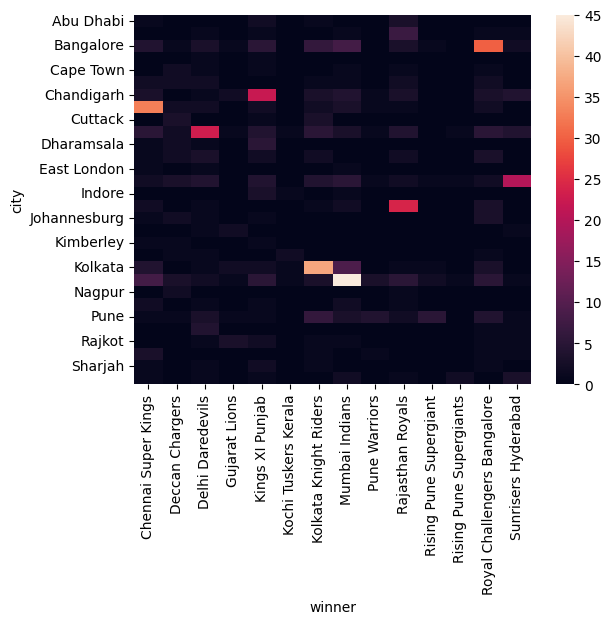

In [22]:
sns.heatmap(result)

In [24]:
# result type by season
result = df.pivot_table(
    index="season",
    columns="result",
    values="id",
    aggfunc="count",
    fill_value=0
)

result

result,no result,normal,tie
season,,,
2008,0,58,0
2009,0,56,1
2010,0,59,1
2011,1,72,0
2012,0,74,0
2013,0,74,2
2014,0,59,1
2015,2,56,1
2016,0,60,0


<Axes: xlabel='result', ylabel='season'>

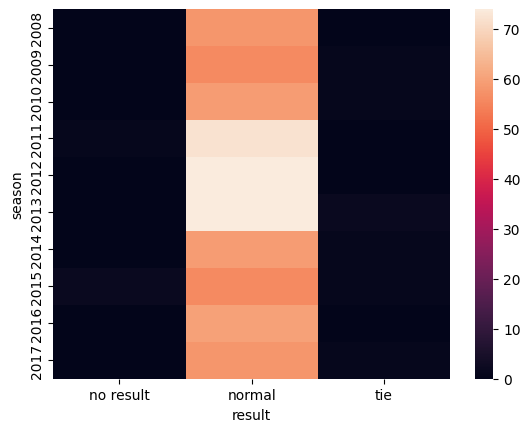

In [25]:
sns.heatmap(result)

# diffrence between pivot() and pivot_table()

**Using pivot()**

we need :- 
**first**

     temp = (
    df.groupby(["season", "winner"])
      .size()
      .reset_index(name="wins")
)


**then**

    temp.pivot(
    index="season",
    columns="winner",
    values="wins"
)



**Using pivot_table()**

we can do everything directly.

     df.pivot_table(
    index="season",
    columns="winner",
    values="id",
    aggfunc="count",
    fill_value=0
)


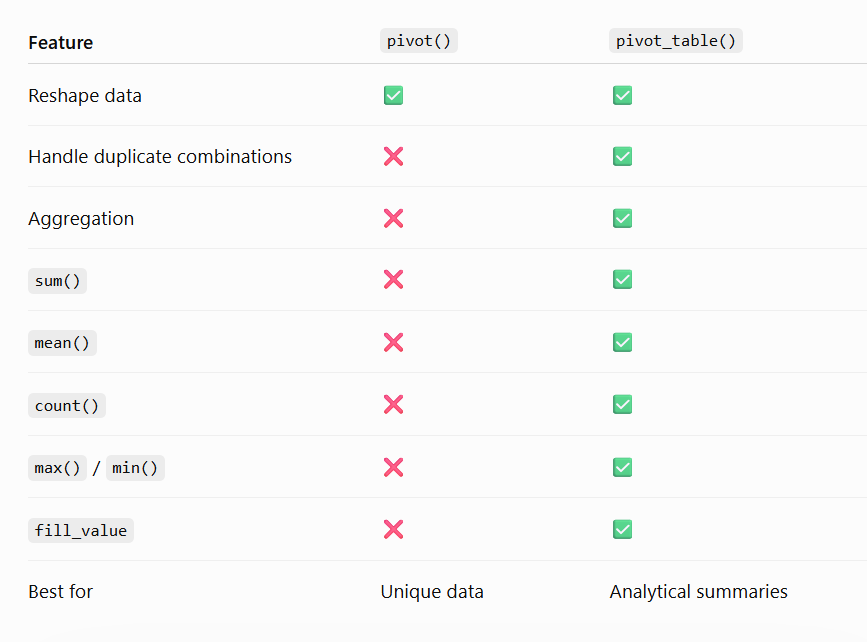